<a href="https://colab.research.google.com/github/Hitesh-3084/gaming-behavior-prediction/blob/main/GamingBehaviourProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [9]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/online_gaming_behavior_dataset.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
# Explore the dataset

df

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,avg_session_length,avg_session_length_per_day
0,9000,43,1,2,4,16.271119,0,2,6,108,79,25,2,2.711853,2.711853
1,9001,29,0,3,4,5.525961,0,2,5,144,11,10,2,1.105192,1.105192
2,9002,22,0,3,3,8.223755,0,0,16,142,35,41,0,0.513985,0.513985
3,9003,35,1,3,0,5.265351,1,0,9,85,57,47,2,0.585039,0.585039
4,9004,33,1,1,0,15.531945,0,2,2,131,95,37,2,7.765972,7.765972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,1,3,4,20.619662,0,0,4,75,85,14,2,5.154916,5.154916
40030,49030,44,0,2,2,13.539280,0,1,19,114,71,27,0,0.712594,0.712594
40031,49031,15,0,3,1,0.240057,1,0,10,176,29,1,0,0.024006,0.024006
40032,49032,34,1,3,3,14.017818,1,2,3,128,70,10,2,4.672606,4.672606


In [34]:
df.isnull().sum()

,0
PlayerID,0
Age,0
Gender,0
Location,0
GameGenre,0
PlayTimeHours,0
InGamePurchases,0
GameDifficulty,0
SessionsPerWeek,0
AvgSessionDurationMinutes,0


In [35]:
import numpy as np

# Create a new column 'avg_session_length_per_day'
# Handle division by zero: if SessionsPerWeek is 0, avg_session_length_per_day should be 0.
# Otherwise, calculate PlayTimeHours / SessionsPerWeek.
df['avg_session_length_per_day'] = np.where(
    df['SessionsPerWeek'] == 0,
    0,
    df['PlayTimeHours'] / df['SessionsPerWeek']
)

# The 'avg_session_length' column was created with the exact same formula.
# To maintain consistency, apply the same logic. It will be dropped from features later.
df['avg_session_length'] = df['avg_session_length_per_day']

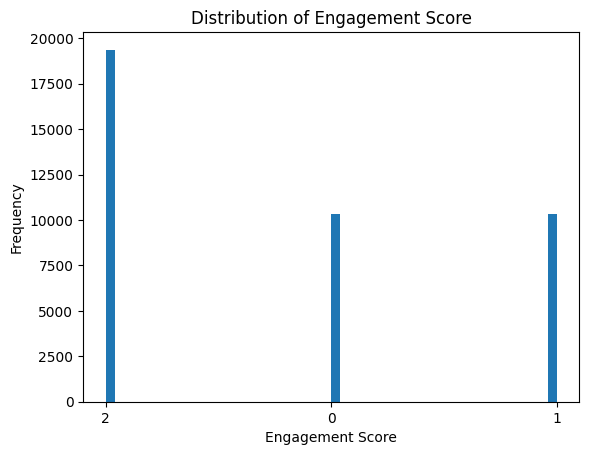

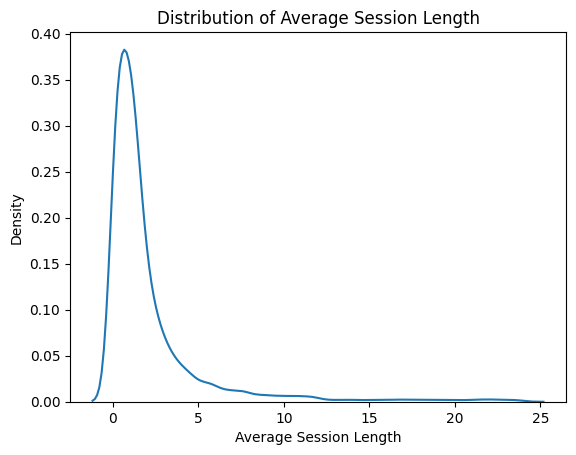

In [36]:
# Distribution of Variables:

import matplotlib.pyplot as plt
import seaborn as sns

df['EngagementLevel'] = df['EngagementLevel'].astype(str)
# histogram of engagement score
plt.hist(df['EngagementLevel'], bins=50)
plt.title('Distribution of Engagement Score')
plt.xlabel('Engagement Score')
plt.ylabel('Frequency')
plt.show()

# density plot of average session length
sns.kdeplot(df['avg_session_length'])
plt.title('Distribution of Average Session Length')
plt.xlabel('Average Session Length')
plt.ylabel('Density')
plt.show()                                 #This will help us understand the shape of each variable's distribution.

                            PlayerID       Age    Gender  Location  GameGenre  \
PlayerID                    1.000000 -0.003044 -0.001847 -0.003001  -0.002314   
Age                        -0.003044  1.000000 -0.002075  0.005701   0.004343   
Gender                     -0.001847 -0.002075  1.000000 -0.004895  -0.005513   
Location                   -0.003001  0.005701 -0.004895  1.000000   0.008941   
GameGenre                  -0.002314  0.004343 -0.005513  0.008941   1.000000   
PlayTimeHours               0.000923  0.002462  0.006514 -0.006206  -0.004226   
InGamePurchases             0.002321 -0.000186  0.006198 -0.007115   0.012843   
GameDifficulty              0.006249 -0.002307  0.006612  0.001229   0.007700   
SessionsPerWeek            -0.005944  0.008777 -0.006491 -0.001939   0.005616   
AvgSessionDurationMinutes  -0.001801 -0.002269 -0.003175  0.005553   0.008697   
PlayerLevel                -0.001769  0.001353  0.006645  0.002514   0.003220   
AchievementsUnlocked        

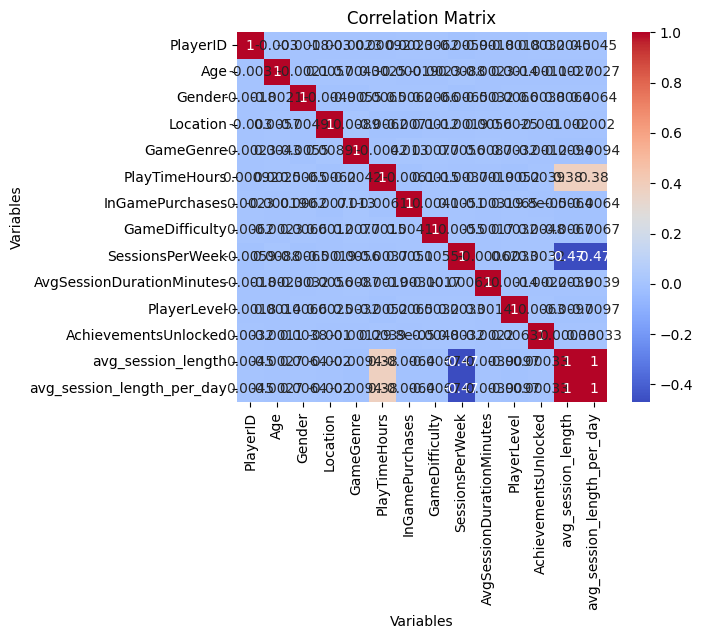

In [37]:
#  Correlation Analysis:

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

# correlation matrix
corr_matrix = numeric_df.corr()
print(corr_matrix)

# heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.show()                             ##This will help us identify relationships between variables.

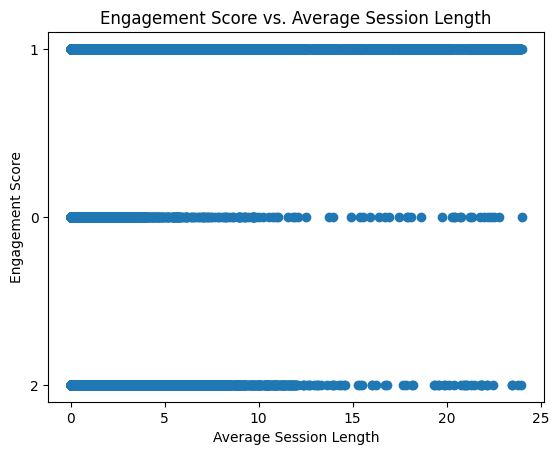

Index(['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours',
       'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek',
       'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked',
       'EngagementLevel', 'avg_session_length', 'avg_session_length_per_day'],
      dtype='object')


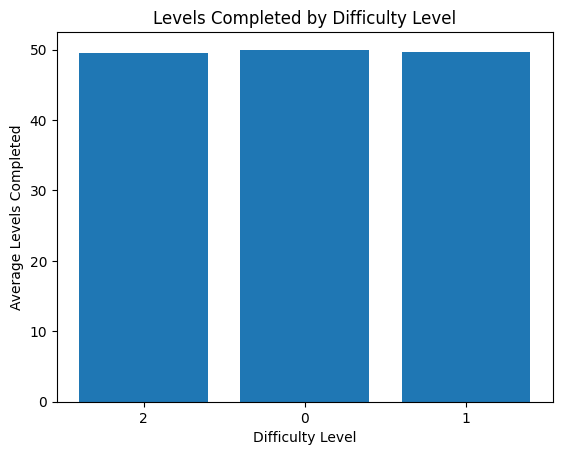

In [38]:
#  Visualization:

import matplotlib.pyplot as plt

# scatter plot of engagement score vs. average session length
plt.scatter(df['avg_session_length'], df['EngagementLevel'])
plt.title('Engagement Score vs. Average Session Length')
plt.xlabel('Average Session Length')
plt.ylabel('Engagement Score')
plt.show()

# Check if there are any columns related to levels completed
print(df.columns)

# Convert 'GameDifficulty' to string before plotting
df['GameDifficulty'] = df['GameDifficulty'].astype(str)

# bar chart of levels completed by difficulty level
plt.bar(df['GameDifficulty'].unique(), df.groupby('GameDifficulty')['PlayerLevel'].mean())

plt.title('Levels Completed by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Average Levels Completed')
plt.show()                             ##This will help us identify patterns and relationships between variables.

In [39]:
df['Gender'].value_counts()

,count
Gender,
1,23959
0,16075


In [40]:
df['Location'].value_counts()

,count
Location,
3,16000
1,12004
0,8095
2,3935


In [41]:
df['GameGenre'].value_counts()

,count
GameGenre,
3,8048
0,8039
4,8012
2,7983
1,7952


In [42]:
df['GameDifficulty'].value_counts()

,count
GameDifficulty,
0,20015
2,12011
1,8008


In [43]:
df['EngagementLevel'].value_counts()

,count
EngagementLevel,
2,19374
0,10336
1,10324


In [45]:
from sklearn.preprocessing import LabelEncoder

In [46]:
lb = LabelEncoder()

In [47]:
df['Gender'] = lb.fit_transform(df['Gender'])
df['Location'] = lb.fit_transform(df['Location'])
df['GameGenre'] = lb.fit_transform(df['GameGenre'])
df['GameDifficulty'] = lb.fit_transform(df['GameDifficulty'])
df['EngagementLevel'] = lb.fit_transform(df['EngagementLevel'])

In [48]:
df.head(3)

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,avg_session_length,avg_session_length_per_day
0,9000,43,1,2,4,16.271119,0,2,6,108,79,25,2,2.711853,2.711853
1,9001,29,0,3,4,5.525961,0,2,5,144,11,10,2,1.105192,1.105192
2,9002,22,0,3,3,8.223755,0,0,16,142,35,41,0,0.513985,0.513985


In [49]:
# Define features (x) and target (y)
# Drop 'PlayerID' as it's an identifier and not a predictive feature.
# Drop 'avg_session_length' as it is identical to the target variable 'avg_session_length_per_day'.
x = df.drop(columns=['PlayerID', 'avg_session_length', 'avg_session_length_per_day'], axis=1)
y = df['avg_session_length_per_day']

In [50]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 ,
                                                       random_state = 42)

In [51]:
print("Total data shape : ",df.shape)
print("Independent data shape : ",x.shape)
print("Dependent data shape : ",y.shape)
print("x_train data shape : ",x_train.shape)
print("x_test data shape : ",x_test.shape)
print("y_train data shape : ",y_train.shape)
print("y_test data shape : ",y_test.shape)

Total data shape :  (40034, 15)
Independent data shape :  (40034, 12)
Dependent data shape :  (40034,)
x_train data shape :  (32027, 12)
x_test data shape :  (8007, 12)
y_train data shape :  (32027,)
y_test data shape :  (8007,)


In [52]:
np.round(x_train.describe())

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
count,32027.0,32027.0,32027.0,32027.0,32027.0,32027.0,32027.0,32027.0,32027.0,32027.0,32027.0,32027.0
mean,32.0,1.0,2.0,2.0,12.0,0.0,1.0,9.0,95.0,50.0,25.0,1.0
std,10.0,0.0,1.0,1.0,7.0,0.0,1.0,6.0,49.0,29.0,14.0,1.0
min,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,1.0,0.0,0.0
25%,23.0,0.0,1.0,1.0,6.0,0.0,0.0,4.0,53.0,25.0,12.0,0.0
50%,32.0,1.0,1.0,2.0,12.0,0.0,1.0,9.0,95.0,50.0,25.0,1.0
75%,41.0,1.0,3.0,3.0,18.0,0.0,2.0,14.0,138.0,74.0,37.0,2.0
max,49.0,1.0,3.0,4.0,24.0,1.0,2.0,19.0,179.0,99.0,49.0,2.0


In [53]:
# STANDARDIZATION

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

# 'inf' values are now handled during column creation, and no other NaNs are present (checked by df.isnull().sum()).
# So, no need for replace([np.inf, -np.inf], np.nan) or dropna() here.
x_train_sc = sc.fit_transform(x_train)
x_train_new = pd.DataFrame(x_train_sc , columns = x.columns)

np.round(x_train_new.describe() , 2)

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
count,32027.00,32027.00,32027.00,32027.00,32027.00,32027.0,32027.00,32027.00,32027.00,32027.00,32027.00,32027.00
mean,-0.00,0.00,0.00,-0.00,0.00,-0.0,-0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.69,-1.22,-1.43,-1.42,-1.74,-0.5,-0.92,-1.65,-1.73,-1.70,-1.70,-1.47
25%,-0.89,-1.22,-0.59,-0.71,-0.86,-0.5,-0.92,-0.95,-0.85,-0.87,-0.87,-1.47
50%,0.00,0.82,-0.59,-0.00,-0.00,-0.5,0.23,-0.08,0.00,0.01,0.03,-0.27
75%,0.90,0.82,1.09,0.71,0.86,-0.5,1.38,0.78,0.88,0.85,0.86,0.93
max,1.70,0.82,1.09,1.41,1.73,2.0,1.38,1.65,1.72,1.72,1.69,0.93


In [54]:
# NORMALIZATION

from sklearn.preprocessing import MinMaxScaler
mn = MinMaxScaler()

# 'inf' values are now handled during column creation, and no other NaNs are present.
# So, no need for replace([np.inf, -np.inf], np.nan) or dropna() here.
x_train_mn = mn.fit_transform(x_train) # Apply scaler to the original x_train data
x_train_new = pd.DataFrame(x_train_mn , columns = x.columns)

np.round(x_train_new.describe(),2)

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
count,32027.00,32027.00,32027.00,32027.00,32027.00,32027.0,32027.00,32027.00,32027.00,32027.00,32027.00,32027.00
mean,0.50,0.60,0.57,0.50,0.50,0.2,0.40,0.50,0.50,0.50,0.50,0.61
std,0.30,0.49,0.40,0.35,0.29,0.4,0.44,0.30,0.29,0.29,0.29,0.42
min,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.24,0.00,0.33,0.25,0.25,0.0,0.00,0.21,0.25,0.24,0.24,0.00
50%,0.50,1.00,0.33,0.50,0.50,0.0,0.50,0.47,0.50,0.50,0.51,0.50
75%,0.76,1.00,1.00,0.75,0.75,0.0,1.00,0.74,0.76,0.74,0.76,1.00
max,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00


RandomForestClassifier

In [55]:
import numpy as np
import pandas as pd


In [56]:
x = df.drop(columns = ['avg_session_length_per_day'] , axis=1)
y = df['avg_session_length_per_day']

from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 ,
                                                       random_state = 42)


In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

# Instantiate MinMaxScaler
mn_scaler = MinMaxScaler()

# Fit the scaler on x_train and transform both x_train and x_test
x_train_scaled = mn_scaler.fit_transform(x_train)
x_test_scaled = mn_scaler.transform(x_test)

# Convert scaled arrays back to DataFrames, retaining column names and indices
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x.columns, index=x_train.index)
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x.columns, index=x_test.index)

# Initialize and train the RandomForestRegressor model
# Added random_state for reproducibility
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train_scaled_df, y_train)

# Make predictions on the scaled test set
y_pred = rf.predict(x_test_scaled_df)

# Evaluate the model using R2 score
r2_score(y_test, y_pred)

0.9999995788445158

In [60]:
print(f"R2 score of the model: {r2_score(y_test , y_pred)}")

R2 score of the model: 0.9999995788445158
